# Question 1 - NN Basics

In [15]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

## I. Fitting Data 

Simulate the following DGP: y = sin(x)+ε. You can consider x∈[0,2π]

In [16]:
np.random.seed(123)

n = 1000

# Simulamos los valores de x en el intervalo [0, 2π] con tamaño (n, 1) para que sea un vector columna.
X = np.random.uniform(0, 2 * np.pi, size=(n, 1))

# Definimos el término de error ε usando una distribución Normal con media 0 y desviación estándar 0.15.
eps = np.random.normal(0, 0.15, size=(n, 1))

y = np.sin(X) + eps

Next, train a NN to predict y with 3 hidden layers, each with 50 neurons. Try the following activation functions:
- logistic
- tanh
- relu

In [17]:
modelos = {} 

# 1) RED CON ACTIVACIÓN LOGISTIC (sigmoid)
# ----------------------------------------
# - random_state=42: para que los resultados sean reproducibles
mlp_logistic = MLPRegressor(
    hidden_layer_sizes=(50, 50, 50), # 3 hidden layers, cada una con 50 neuronas
    activation='logistic',           # función sigmoide, buena para capturar no linealidades suaves
    solver='adam',                   # optimizador basado en gradiente (por defecto, funciona bien)
    learning_rate_init=0.01,         # tasa de aprendizaje inicial
    max_iter=5000,                   # número máximo de iteraciones para asegurar que le damos tiempo a converger
    random_state=123
)

mlp_logistic.fit(X, y.ravel())       # Entrenamos la red: encuentra los pesos que mejor ajustan y ≈ f(x)

modelos['logistic'] = mlp_logistic   # Guardamos el modelo entrenado en el diccionario

In [18]:
# 2) RED CON ACTIVACIÓN TANH
# ---------------------------
mlp_tanh = MLPRegressor(
    hidden_layer_sizes=(50, 50, 50),
    activation='tanh', # función tangente hiperbólica, toma valores entre -1 y 1.
    solver='adam',
    learning_rate_init=0.01,
    max_iter=5000,
    random_state=123
)

mlp_tanh.fit(X, y.ravel())

modelos['tanh'] = mlp_tanh

In [19]:
# 3) RED CON ACTIVACIÓN ReLU
# ---------------------------
mlp_relu = MLPRegressor(
    hidden_layer_sizes=(50, 50, 50),
    activation='relu', # Rectified Linear Unit: f(z) = max(0, z)
    solver='adam',
    learning_rate_init=0.01,
    max_iter=5000,
    random_state=123
)

mlp_relu.fit(X, y.ravel())

modelos['relu'] = mlp_relu

Finally, train another NN with the same characteristics but using a different activation function for each hidden layer (you can leave any other parameters as default when training the NN).

In [20]:
# Convertir datos a tensores (PyTorch solo puede trabajar con tensores, no con arrays de NumPy.)
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)

# Red neuronal con activaciones mixtas
class MixedNN(nn.Module):
    def __init__(self):
        super().__init__()
        # nn.Sequential encadena capas y funciones de activación en orden
        self.net = nn.Sequential(
            nn.Linear(1, 50),
            nn.Tanh(),       # 1ª capa -> tanh
            nn.Linear(50, 50),
            nn.ReLU(),       # 2ª capa -> ReLU
            nn.Linear(50, 50),
            nn.Sigmoid(),    # 3ª capa -> sigmoid
            nn.Linear(50, 1) # salida
        )

    def forward(self, x):
        # Basta con pasar la entrada a self.net, que ya tiene todo el flujo definido
        return self.net(x)

# Crear el modelo, pérdida y optimizador
model = MixedNN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 🔁 Entrenamiento compacto
for epoch in range(4000):
    optimizer.zero_grad()
    loss = criterion(model(X_t), y_t)
    loss.backward()
    optimizer.step()
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss={loss.item():.4f}")

model_mixto = model
modelos['mixto'] = model_mixto

Epoch 0, Loss=0.5862
Epoch 1000, Loss=0.0206
Epoch 2000, Loss=0.0207
Epoch 3000, Loss=0.0205


For each NN trained, plot the data and the fitted values in the XY-plane
Which NN fits the data better?

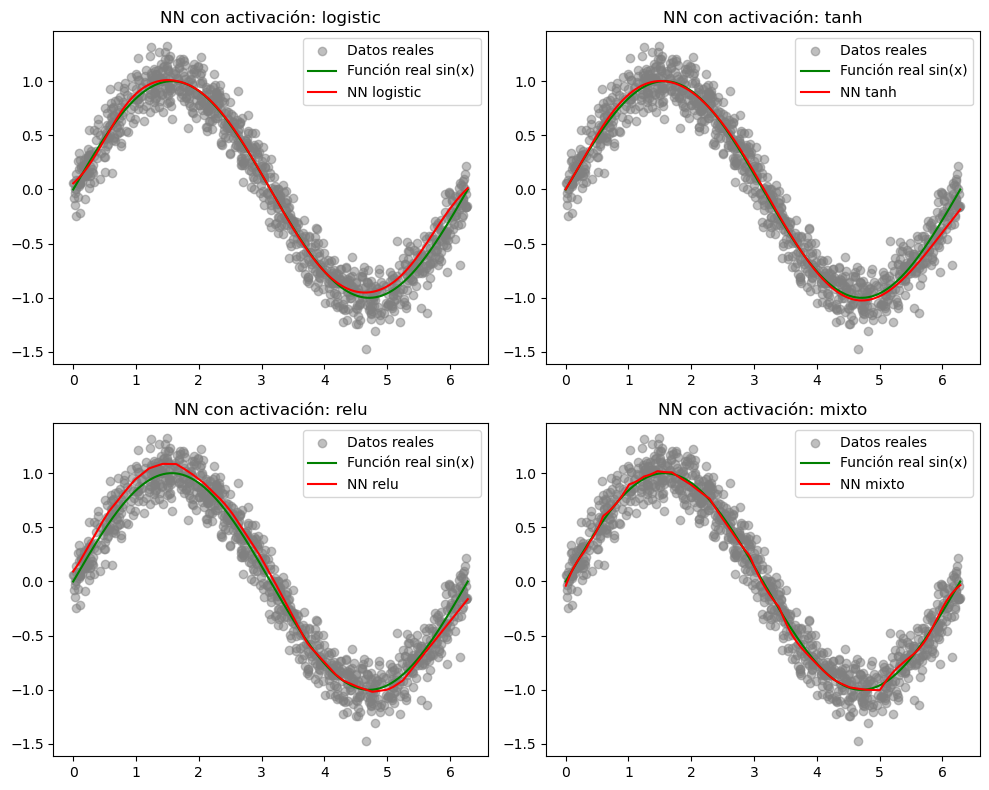

In [21]:
# Crear grilla para graficar
x_grid = np.linspace(0, 2 * np.pi, 500).reshape(-1, 1)
y_true = np.sin(x_grid)

predicciones = {}

# 🔧 Este bloque detecta si el modelo es de sklearn o PyTorch
for nombre, modelo in modelos.items():
    if hasattr(modelo, "predict"):  # Caso sklearn
        y_pred = modelo.predict(x_grid)
    else:  # Caso PyTorch
        modelo.eval()                
        x_t = torch.tensor(x_grid, dtype=torch.float32)
        with torch.no_grad():
            y_pred = modelo(x_t).detach().cpu().numpy()
    predicciones[nombre] = y_pred

# Graficamos los 4 resultados
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (nombre, y_pred) in zip(axes, predicciones.items()):
    ax.scatter(X, y, color='gray', alpha=0.5, label='Datos reales')
    ax.plot(x_grid, y_true, color='green', label='Función real sin(x)')
    ax.plot(x_grid, y_pred, color='red', label=f'NN {nombre}')
    ax.set_title(f"NN con activación: {nombre}")
    ax.legend()

plt.tight_layout()
plt.show()

In [22]:
# Calcular el MSE de cada modelo comparando con la función real sin(x)
mse_resultados = {}

for nombre, y_pred in predicciones.items():
    mse = mean_squared_error(np.sin(x_grid), y_pred)
    mse_resultados[nombre] = mse
    print(f"{nombre:10s} -> MSE: {mse:.6f}")

# Identificar cuál modelo tiene el menor error
mejor_modelo = min(mse_resultados, key=mse_resultados.get)
print("\n✅ Mejor modelo según MSE:", mejor_modelo)

logistic   -> MSE: 0.002223
tanh       -> MSE: 0.001857
relu       -> MSE: 0.004381
mixto      -> MSE: 0.000411

✅ Mejor modelo según MSE: mixto


## II. Learning-rate

Briefly explain what the learning-rate is in the context of Neural Networks.

- The learning rate in a neural network is basically the speed at which the model learns.

- During training, the network adjusts its internal parameters (weights) to reduce prediction errors — kind of like how an economist updates expectations when new data comes in. The learning rate determines how big those adjustments are each time the model learns from the data.

- If the learning rate is too high, the model makes big jumps and might miss the best solution.

- If it’s too low, it moves very slowly and can get stuck before reaching the optimal point.

Use the same data simulation and the activation function that performed better between logistic, tanh, and relu. Iterate over the following learning rates training for each iteration a NN of a single hidden layer with 50 neurons. 0.0001, 0.001, 0.01, 0.1

In [23]:
# Define learning rates to test
learning_rates = [0.0001, 0.001, 0.01, 0.1]
modelos_lr = {}
predicciones_lr = {}
mse_lr = {}

# Train a NN for each learning rate using the best activation (tanh)
for lr in learning_rates:
    print(f"Training NN with learning rate = {lr}")
    mlp = MLPRegressor(
        hidden_layer_sizes=(50,),   # single hidden layer, 50 neurons
        activation='tanh',          # best activation from previous test
        solver='adam',
        learning_rate_init=lr,
        max_iter=5000,
        random_state=42
    )
    mlp.fit(X, y.ravel())
    
    # Save model and predictions
    modelos_lr[lr] = mlp
    y_pred = mlp.predict(x_grid)
    predicciones_lr[lr] = y_pred
    
    # Calculate MSE vs true sine function
    mse = mean_squared_error(y_true, y_pred)
    mse_lr[lr] = mse

Training NN with learning rate = 0.0001
Training NN with learning rate = 0.001
Training NN with learning rate = 0.01
Training NN with learning rate = 0.1


In one single graph, plot the data and the fitted values in the XY-plane. Properly label the graph and answer which learning rate worked best.

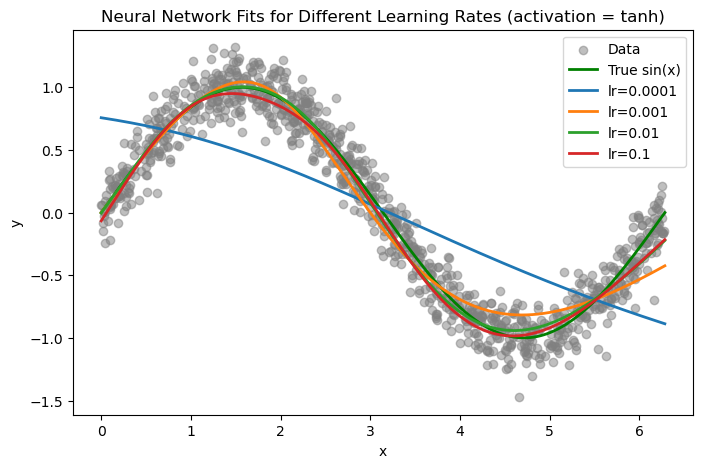

Learning rate 0.0001: MSE = 0.175291
Learning rate 0.001: MSE = 0.014558
Learning rate 0.01: MSE = 0.003414
Learning rate 0.1: MSE = 0.003729

✅ Best learning rate: 0.01 (lowest MSE = 0.003414)


In [24]:
# Single plot to compare all learning rates
plt.figure(figsize=(8, 5))

# Plot original data (gray) and true sine function (green)
plt.scatter(X, y, color='gray', alpha=0.5, label='Data')
plt.plot(x_grid, y_true, color='green', linewidth=2, label='True sin(x)')

# Plot each model’s fitted curve
for lr, y_pred in predicciones_lr.items():
    plt.plot(x_grid, y_pred, linewidth=2, label=f'lr={lr}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Neural Network Fits for Different Learning Rates (activation = tanh)')
plt.legend()
plt.show()

# Calculate and print MSE for each learning rate
mse_lr = {}
for lr, y_pred in predicciones_lr.items():
    mse = mean_squared_error(y_true, y_pred)
    mse_lr[lr] = mse
    print(f"Learning rate {lr}: MSE = {mse:.6f}")

best_lr = min(mse_lr, key=mse_lr.get)
print(f"\n✅ Best learning rate: {best_lr} (lowest MSE = {mse_lr[best_lr]:.6f})")

Repeat this process (training and graph) for a NN with 2 hidden layers, and 3 hidden layers (each layer with 50 neurons).


==================== 1 hidden layer ====================
Training NN with learning rate = 0.0001
Training NN with learning rate = 0.001
Training NN with learning rate = 0.01
Training NN with learning rate = 0.1


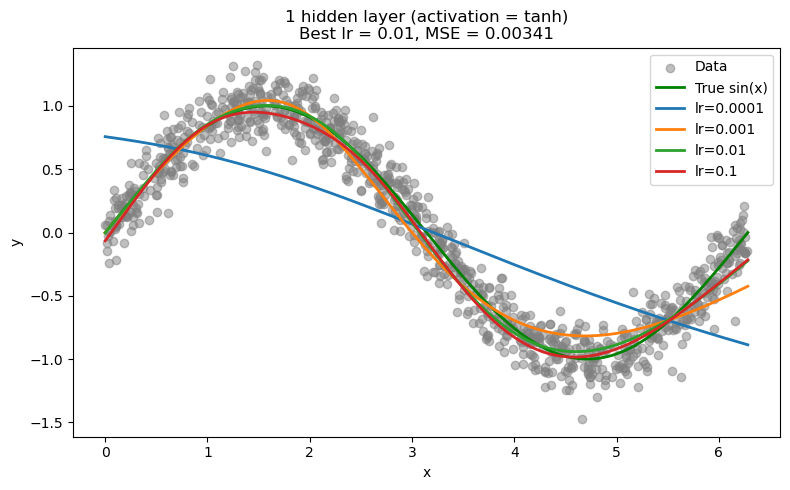

MSE by learning rate:
  lr=0.0001  -> MSE=0.175291
  lr=0.001   -> MSE=0.014558
  lr=0.01    -> MSE=0.003414
  lr=0.1     -> MSE=0.003729
✅ Best learning rate for 1 hidden layer: 0.01 (MSE=0.003414)

==================== 2 hidden layers ====================
Training NN with learning rate = 0.0001
Training NN with learning rate = 0.001
Training NN with learning rate = 0.01
Training NN with learning rate = 0.1


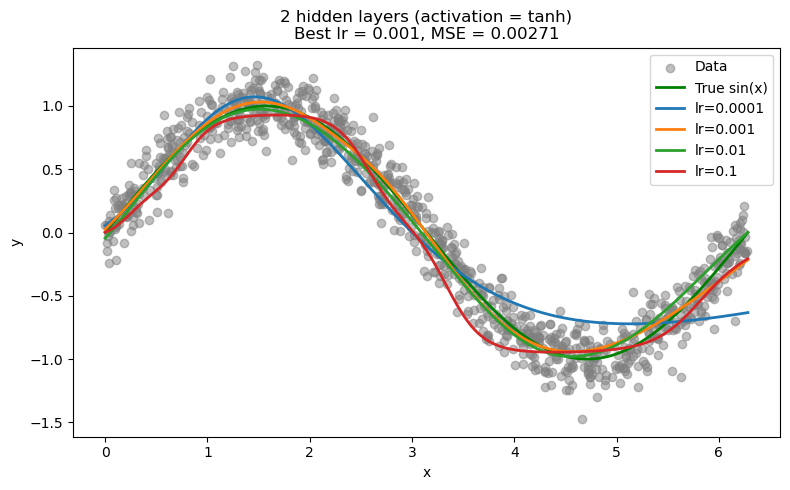

MSE by learning rate:
  lr=0.0001  -> MSE=0.035708
  lr=0.001   -> MSE=0.002710
  lr=0.01    -> MSE=0.003035
  lr=0.1     -> MSE=0.015053
✅ Best learning rate for 2 hidden layers: 0.001 (MSE=0.002710)

==================== 3 hidden layers ====================
Training NN with learning rate = 0.0001
Training NN with learning rate = 0.001
Training NN with learning rate = 0.01
Training NN with learning rate = 0.1


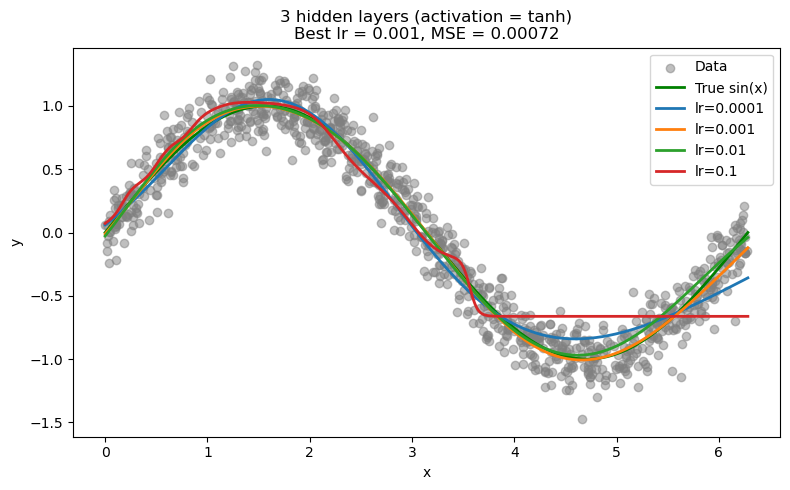

MSE by learning rate:
  lr=0.0001  -> MSE=0.009900
  lr=0.001   -> MSE=0.000723
  lr=0.01    -> MSE=0.001426
  lr=0.1     -> MSE=0.035306
✅ Best learning rate for 3 hidden layers: 0.001 (MSE=0.000723)


In [25]:
architectures = {
    "1 hidden layer": (50,),
    "2 hidden layers": (50, 50),
    "3 hidden layers": (50, 50, 50)
}


# Iterate over each architecture
for arch_name, arch in architectures.items():
    print(f"\n==================== {arch_name} ====================")
    predicciones_lr = {}
    mse_lr = {}

    # Train a model for each learning rate
    for lr in learning_rates:
        print(f"Training NN with learning rate = {lr}")
        mlp = MLPRegressor(
            hidden_layer_sizes=arch,
            activation='tanh',
            solver='adam',
            learning_rate_init=lr,
            max_iter=5000,
            random_state=42
        )
        mlp.fit(X, y.ravel())

        # Predictions and error
        y_pred = mlp.predict(x_grid)
        mse = mean_squared_error(y_true, y_pred)
        predicciones_lr[lr] = y_pred
        mse_lr[lr] = mse

    # Plot all learning rate fits in one single graph
    plt.figure(figsize=(8, 5))
    plt.scatter(X, y, color='gray', alpha=0.5, label='Data')
    plt.plot(x_grid, y_true, color='green', linewidth=2, label='True sin(x)')
    
    for lr, y_pred in predicciones_lr.items():
        plt.plot(x_grid, y_pred, linewidth=2, label=f'lr={lr}')
    
    best_lr = min(mse_lr, key=mse_lr.get)
    plt.title(f"{arch_name} (activation = tanh)\nBest lr = {best_lr}, MSE = {mse_lr[best_lr]:.5f}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print summary
    print("MSE by learning rate:")
    for lr, mse in mse_lr.items():
        print(f"  lr={lr:<7} -> MSE={mse:.6f}")
    print(f"✅ Best learning rate for {arch_name}: {best_lr} (MSE={mse_lr[best_lr]:.6f})")

 In this illustrative example, what can you say about the relationship between the learning rate and the number of hidden layers?

| Architecture    | Best Learning Rate | MSE (lower = better) |
| --------------- | ------------------ | -------------------- |
| 1 hidden layer  | **0.01**           | 0.00341              |
| 2 hidden layers | **0.001**          | 0.00271              |
| 3 hidden layers | **0.001**          | 0.00072              |

As the number of hidden layers increases, the learning rate that works best becomes smaller.
- With 1 hidden layer, the model can tolerate a relatively high learning rate (0.01) because the optimization landscape is simpler.
- With 2 hidden layers, the best learning rate becomes lower (0.001) because the model is deeper and gradients become more unstable.
- With 3 hidden layers, the optimal learning rate stabilizes around 0.001 but higher learning rates (0.1) destabilize training completely.